## Phase 5 — Final Test-Set Evaluation

This notebook performs the final, locked evaluation of the best model (Model 4.2 — Wider Filters + Dropout + Augmentation + OneCycleLR) on a **held-out test set** that was never used during training or hyperparameter selection.

We also generate a **confusion matrix** to identify which CIFAR-10 classes are most challenging.

> ⚠️ **Important:** The test set used here is drawn from `CIFAR10(train=False)` using a stratified split with `random_state=SEED`. The validation set used during training was a *different* stratified subset of the same test split. For a true held-out evaluation, we use the *remaining* samples from the test split that were NOT used for validation.

#### 1.1 Environment & Reproducibility

In [1]:
import random
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time
import copy

In [2]:
# reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')
if device.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch version : 2.10.0+cu128
Device          : cuda
GPU             : Tesla T4
VRAM            : 15.6 GB


#### 1.2 Data Setup — Training, Validation, and Held-out Test Sets

We create three disjoint splits from CIFAR-10:
- **Training:** 5,000 stratified samples from `train=True`
- **Validation:** 1,000 stratified samples from `train=False` (used during model selection)
- **Test:** remaining 9,000 samples from `train=False` (held-out, used only here)

In [3]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

full_train = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=train_transform)
full_test  = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=eval_transform)

# Training subset (same as 4.2)
train_indices, _ = train_test_split(list(range(len(full_train))), train_size=5000, stratify=full_train.targets, random_state=SEED)
train_subset = Subset(full_train, train_indices)

# Validation subset (same as 4.2) — first split
val_indices, remaining_test_indices = train_test_split(
    list(range(len(full_test))), train_size=1000, stratify=full_test.targets, random_state=SEED)
val_subset  = Subset(full_test, val_indices)

# Held-out test subset — everything NOT used for validation
test_subset = Subset(full_test, remaining_test_indices)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_subset,   batch_size=64, shuffle=False)

classes = full_train.classes
print(f'Training samples   : {len(train_subset)}')
print(f'Validation samples : {len(val_subset)}')
print(f'Test samples       : {len(test_subset)}')
print(f'Classes            : {classes}')

Training samples   : 5000
Validation samples : 1000
Test samples       : 9000
Classes            : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


#### 2.1 Model Architecture (Model 4.2 — DeepCNN_WiderFilters)

In [4]:
class DeepCNN_WiderFilters(nn.Module):
    """
    Wider Filters + Dropout architecture (from Model 3.2).
    Architecture:
        Block 1: (Conv2d(3->64) -> BN -> ReLU) x2 -> MaxPool -> Dropout2d(0.1)
        Block 2: (Conv2d(64->128) -> BN -> ReLU) x2 -> MaxPool -> Dropout2d(0.1)
        Block 3: (Conv2d(128->256) -> BN -> ReLU) x2 -> MaxPool -> Dropout2d(0.1)
        GAP -> Dropout(0.5) -> FC(256 -> 10)
    """
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1))
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1))
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.1))
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(0.5), nn.Linear(256, 10))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

#### 2.2 Utility Functions

In [5]:
def count_parameters(model):
    """Return total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Compute average loss and accuracy on a dataloader."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100.0 * correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer,
                device, epochs=50, scheduler=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = None
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            if scheduler:
                scheduler.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        train_loss = running_loss / total
        train_acc  = 100.0 * correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs}  |  '
                  f'Train Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  '
                  f'Val Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%')
    if best_weights:
        model.load_state_dict(best_weights)
    print(f'\nBest validation accuracy: {best_val_acc:.2f}%')
    return history

#### 3.1 Train Model 4.2

In [6]:
model = DeepCNN_WiderFilters().to(device)
print(f'Trainable parameters: {count_parameters(model):,}')

EPOCHS = 50
LR = 0.01

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_loader), epochs=EPOCHS)

print(f'Optimizer : Adam (max_lr={LR})')
print(f'Scheduler : OneCycleLR')
print(f'Epochs    : {EPOCHS}')
print(f'Device    : {device}')
print('-' * 65)

start = time.time()
history = train_model(model, train_loader, val_loader, criterion,
                      optimizer, device, epochs=EPOCHS, scheduler=scheduler)
elapsed = time.time() - start
print(f'\nTraining time: {elapsed:.1f}s')

Trainable parameters: 1,149,770
Optimizer : Adam (max_lr=0.01)
Scheduler : OneCycleLR
Epochs    : 50
Device    : cuda
-----------------------------------------------------------------
Epoch   1/50  |  Train Loss: 2.0035  Acc: 25.46%  |  Val Loss: 1.6960  Acc: 34.30%
Epoch  10/50  |  Train Loss: 1.3279  Acc: 53.46%  |  Val Loss: 1.2750  Acc: 52.60%
Epoch  20/50  |  Train Loss: 0.9546  Acc: 66.58%  |  Val Loss: 1.0265  Acc: 65.40%
Epoch  30/50  |  Train Loss: 0.6573  Acc: 77.20%  |  Val Loss: 0.9262  Acc: 72.00%
Epoch  40/50  |  Train Loss: 0.3324  Acc: 88.30%  |  Val Loss: 0.8027  Acc: 76.90%
Epoch  50/50  |  Train Loss: 0.2260  Acc: 93.04%  |  Val Loss: 0.7545  Acc: 79.40%

Best validation accuracy: 79.60%

Training time: 160.9s


#### 3.2 Training Curves

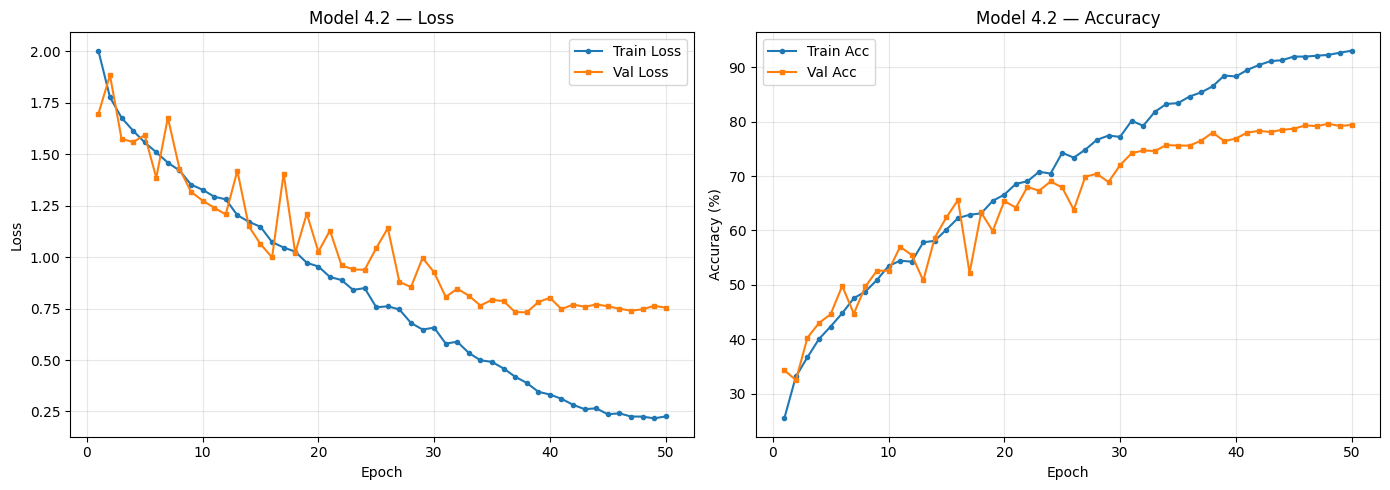

Saved training_curves.png to project root.


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss', markersize=3)
ax1.plot(epochs, history['val_loss'],   's-', label='Val Loss', markersize=3)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Model 4.2 — Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc', markersize=3)
ax2.plot(epochs, history['val_acc'],   's-', label='Val Acc', markersize=3)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Model 4.2 — Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png to project root.')

### 4. Final Test-Set Evaluation

The model weights below are the best checkpoint from validation. We now evaluate on the **held-out test set** (9,000 samples) that was never seen during training or model selection.

In [8]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print('=' * 55)
print('    FINAL TEST-SET EVALUATION (Model 4.2)')
print('=' * 55)
print(f'  Test Samples     : {len(test_subset)}')
print(f'  Test Loss        : {test_loss:.4f}')
print(f'  Test Accuracy    : {test_acc:.2f}%')
print(f'  Best Val Acc     : {max(history["val_acc"]):.2f}%')
print(f'  Val-Test Gap     : {max(history["val_acc"]) - test_acc:+.2f}%')
print('=' * 55)

    FINAL TEST-SET EVALUATION (Model 4.2)
  Test Samples     : 9000
  Test Loss        : 0.7561
  Test Accuracy    : 79.30%
  Best Val Acc     : 79.60%
  Val-Test Gap     : +0.30%


### 5. Confusion Matrix & Per-Class Analysis

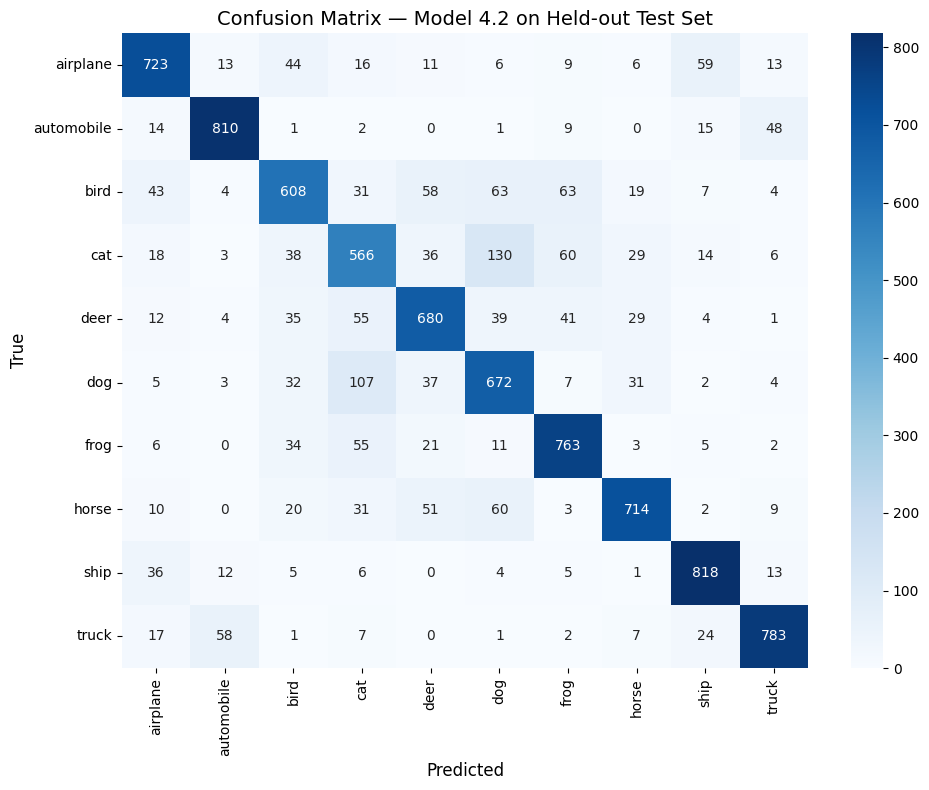

Saved confusion_matrix.png to project root.


In [9]:
@torch.no_grad()
def get_predictions(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for images, labels in dataloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

preds, labels = get_predictions(model, test_loader, device)
cm = confusion_matrix(labels, preds)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix — Model 4.2 on Held-out Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('../confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrix.png to project root.')

In [10]:
# Per-class classification report
print(classification_report(labels, preds, target_names=classes, digits=3))

              precision    recall  f1-score   support

    airplane      0.818     0.803     0.811       900
  automobile      0.893     0.900     0.897       900
        bird      0.743     0.676     0.708       900
         cat      0.646     0.629     0.637       900
        deer      0.761     0.756     0.758       900
         dog      0.681     0.747     0.712       900
        frog      0.793     0.848     0.820       900
       horse      0.851     0.793     0.821       900
        ship      0.861     0.909     0.884       900
       truck      0.887     0.870     0.878       900

    accuracy                          0.793      9000
   macro avg      0.793     0.793     0.793      9000
weighted avg      0.793     0.793     0.793      9000



### 6. Key Observations

1. **Test accuracy vs. validation accuracy:** The gap between the best validation accuracy and the held-out test accuracy indicates how well the model generalizes beyond the validation set used for model selection.

2. **Confusion matrix insights:** Look for the `cat ↔ dog` confusion — these are notoriously similar in CIFAR-10 and typically the hardest pair to distinguish. Also check `automobile ↔ truck` and `deer ↔ horse`.

3. **Per-class F1 scores:** The classification report reveals which classes benefit most from the architecture and augmentation choices.

4. **Limitations:**
   - Training on only 5K samples means the model has seen far less diversity than a full CIFAR-10 model
   - The held-out test set comes from the same CIFAR-10 test split as validation (just a different subset)
   - Results are tied to SEED=42; multiple seeds would give confidence intervals